# MMD-GAN on MNIST — Autoencoder critic (canonical recipe)

**Reference:** Li, Chang, Cheng, Yang, Póczos — *MMD GAN: Towards Deeper Understanding of
Moment Matching Network*, NeurIPS 2017, and the widely-used PyTorch implementation
(`OctoberChang/MMD-GAN`). Also Bińkowski et al., *Demystifying MMD GANs*, ICLR 2018.

## Why the previous versions failed

| Version | Symptom | Cause |
|---|---|---|
| `λ_act = 0` | learned (KID → ~0.8) but unstable late | critic feature norms exploded, saturating the kernel |
| target activation penalty (`λ_act = 1`) | **never learned** — KID stuck ~3.0, samples collapse to black | clamping the feature *scale* crippled the critic; it separated on a trivial statistic and the generator won by going blank |

Forcing the feature **scale** was the wrong lever. The fix is to force the features to stay
**informative**, which is what the reference MMD-GAN does.

## What this version does (canonical autoencoder MMD-GAN)

1. **Autoencoder critic.** The critic *encodes* the image to a code (used for MMD) and a
   *decoder* reconstructs the image. A reconstruction loss (`λ_AE`) forces the code to retain
   real image structure, so the critic cannot collapse onto a degenerate feature and the
   generator cannot win by producing blank images.
2. **Spectral normalisation on the encoder** — a robust Lipschitz constraint (replaces the
   original repo's weight clipping / the gradient penalty). Keeps features controlled **without**
   clamping their scale.
3. **MMD on the codes** with an RBF-kernel mixture, optimised as **√(MMD²)** (the reference's
   more stable objective).
4. **`n_critic = 5`** — the critic is trained harder than the generator.
5. Kept from before: **frozen-LeNet KID** (honest metric), **EMA generator**, and **all outputs
   saved to disk** (`outputs/`), plus a **best-by-KID checkpoint**.

The gradient penalty and the activation penalty are **removed** — the autoencoder + spectral
norm replace them.


## 1. Imports and Configuration

In [11]:
import os
import math
import time
import json

from copy import deepcopy
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

torch.manual_seed(0)
np.random.seed(0)

# ── Output directories (figures, logs and checkpoints are all written to disk) ─
OUTPUT_DIR = 'outputs'
IMG_DIR    = os.path.join(OUTPUT_DIR, 'images')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

def save_fig(name):
    path = os.path.join(IMG_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    return path


device: cuda


In [12]:
@dataclass
class Config:
    # Data
    img_size:    int   = 28
    channels:    int   = 1
    batch_size:  int   = 128

    # Architecture
    z_dim:       int   = 100
    feat_dim:    int   = 32    # autoencoder CODE size (the MMD feature)
    g_filters:   int   = 64    # generator / decoder filters
    d_filters:   int   = 32    # encoder filters

    # MMD / critic regularisation
    lambda_ae:   float = 8.0   # weight of the autoencoder reconstruction loss (keeps codes informative)

    # Optimisation
    lr_G:        float = 1e-4
    lr_D:        float = 1e-4
    beta1:       float = 0.5
    beta2:       float = 0.9
    n_critic:    int   = 5     # critic updates per generator update (reference uses 5)
    n_iters:     int   = 10_000
    lr_decay_start: int = 40_000   # gentle linear LR decay -> 0 over the tail
    log_every:   int   = 200
    sample_every:int   = 1_000

cfg = Config()
print(cfg)


Config(img_size=28, channels=1, batch_size=128, z_dim=100, feat_dim=32, g_filters=64, d_filters=32, lambda_ae=8.0, lr_G=0.0001, lr_D=0.0001, beta1=0.5, beta2=0.9, n_critic=5, n_iters=10000, lr_decay_start=40000, log_every=200, sample_every=1000)


## 2. Data: MNIST

Images normalised to [-1, 1] to match the generator's `tanh` output.


Batch shape: torch.Size([128, 1, 28, 28])  min/max: -1.0 1.0


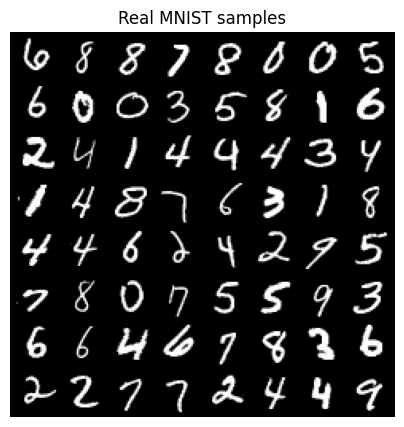

In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_set = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=2, drop_last=True, pin_memory=True)

def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

data_iter = infinite_loader(train_loader)
x_demo, _ = next(data_iter)
print('Batch shape:', x_demo.shape, ' min/max:', x_demo.min().item(), x_demo.max().item())

fig, ax = plt.subplots(figsize=(5, 5))
grid = utils.make_grid(x_demo[:64], nrow=8, normalize=True, value_range=(-1, 1))
ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
ax.set_title('Real MNIST samples'); ax.axis('off')
save_fig('real_samples.png'); plt.show(); plt.close()


## 3. Generator and Autoencoder Critic

The **generator** is a standard DCGAN. The **critic is an autoencoder**: an *encoder*
maps the image to a `feat_dim`-dimensional **code** (the feature on which MMD is computed),
and a *decoder* reconstructs the image from that code.

Why an autoencoder? MMD only measures how well the generated codes match the real codes.
If the encoder is unconstrained it can map everything to a trivial statistic that the
generator then satisfies with blank images (exactly the collapse seen earlier). The
**reconstruction loss forces the code to carry real image content**, so matching codes means
matching digits. The encoder is **spectral-normalised** to keep it Lipschitz (a robust
replacement for weight clipping / gradient penalty).


In [14]:
class Generator(nn.Module):
    '''z (B, z_dim) -> image (B, 1, 28, 28) in [-1, 1].'''
    def __init__(self, z_dim=100, ngf=64, channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf * 4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.Conv2d(ngf, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class AECritic(nn.Module):
    '''Autoencoder critic.
        encode(x) -> code (B, feat_dim)          # the MMD feature
        forward(x) -> (code, reconstruction)
    Encoder is spectral-normalised (Lipschitz); decoder mirrors the generator.
    '''
    def __init__(self, channels=1, ndf=32, ngf=64, code_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(channels, ndf, 4, 2, 1)),          # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1)),           # 14 -> 7
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1)),       # 7  -> 3
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            spectral_norm(nn.Linear(ndf * 4 * 3 * 3, code_dim)),
        )
        self.dec_fc = nn.Sequential(
            nn.Linear(code_dim, ngf * 4 * 7 * 7),
            nn.BatchNorm1d(ngf * 4 * 7 * 7), nn.ReLU(True),
        )
        self.ngf4 = ngf * 4
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False), # 7  -> 14
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),     # 14 -> 28
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.Conv2d(ngf, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, code):
        h = self.dec_fc(code).view(-1, self.ngf4, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        code = self.encode(x)
        rec  = self.decode(code)
        return code, rec


G = Generator(cfg.z_dim, cfg.g_filters, cfg.channels).to(device)
D = AECritic(cfg.channels, cfg.d_filters, cfg.g_filters, cfg.feat_dim).to(device)

print(f'Generator : {sum(p.numel() for p in G.parameters()):,} params')
print(f'Critic(AE): {sum(p.numel() for p in D.parameters()):,} params')

# Sanity check
with torch.no_grad():
    fake_test = G(torch.randn(8, cfg.z_dim, device=device))
    code_test, rec_test = D(fake_test)
print('fake:', tuple(fake_test.shape), ' code:', tuple(code_test.shape), ' recon:', tuple(rec_test.shape))


Generator : 1,911,232 params
Critic(AE): 1,296,832 params
fake: (8, 1, 28, 28)  code: (8, 32)  recon: (8, 1, 28, 28)


## 4. Adaptive RBF-mixture kernel and unbiased MMD²

MMD is computed on the encoder **codes** with a mixture of RBF kernels
$k(x,y)=\sum_c \exp(-\|x-y\|^2 / c\,\sigma_0^2)$. The base bandwidth $\sigma_0^2$ is set per
batch by the **median-distance heuristic** (the median pairwise squared distance of the
codes), so the kernel automatically tracks the code scale instead of needing a hand-tuned
sigma — important here because spectral norm keeps the codes small.

$$\widehat{\mathrm{MMD}}^2_u = \frac{1}{m(m{-}1)}\sum_{i\neq j}k(x_i,x_j) + \frac{1}{n(n{-}1)}\sum_{i\neq j}k(y_i,y_j) - \frac{2}{mn}\sum_{i,j}k(x_i,y_j)$$


In [15]:
# Adaptive RBF-mixture kernel: bandwidths set by the MEDIAN-DISTANCE HEURISTIC,
# so the kernel tracks the (spectral-norm-bounded) code scale -- no sigma to hand-tune.
RBF_MULTS = (0.25, 0.5, 1.0, 2.0, 4.0)   # bandwidth multipliers around the median distance
ALPHAS    = (0.2, 0.5, 1., 2., 5.)       # RQ mixture (used only by the KID monitor)

def _sqdist(x, y):
    '''Pairwise squared Euclidean distances. x:(m,d), y:(n,d) -> (m,n).'''
    xx = (x * x).sum(1, keepdim=True)
    yy = (y * y).sum(1, keepdim=True).t()
    return (xx + yy - 2.0 * (x @ y.t())).clamp_(min=0)

def _median_scale(d2):
    '''Median of off-diagonal squared distances (detached) — the RBF bandwidth base.'''
    n = d2.size(0)
    mask = ~torch.eye(n, dtype=torch.bool, device=d2.device)
    return d2[mask].median().detach().clamp_min(1e-8)

def _rbf_mix(d2, base):
    return sum(torch.exp(-d2 / (c * base)) for c in RBF_MULTS)

def mmd2_rbf_adaptive(f_x, f_y):
    '''Unbiased MMD² with a median-heuristic RBF mixture on features f_x, f_y.'''
    m, n = f_x.size(0), f_y.size(0)
    assert m > 1 and n > 1
    base = _median_scale(_sqdist(torch.cat([f_x, f_y], 0), torch.cat([f_x, f_y], 0)))
    k_xx = _rbf_mix(_sqdist(f_x, f_x), base)
    k_yy = _rbf_mix(_sqdist(f_y, f_y), base)
    k_xy = _rbf_mix(_sqdist(f_x, f_y), base)
    eye_m = torch.eye(m, dtype=torch.bool, device=f_x.device)
    eye_n = torch.eye(n, dtype=torch.bool, device=f_y.device)
    sum_xx = k_xx.masked_fill(eye_m, 0).sum() / (m * (m - 1))
    sum_yy = k_yy.masked_fill(eye_n, 0).sum() / (n * (n - 1))
    sum_xy = k_xy.sum() / (m * n)
    return sum_xx + sum_yy - 2.0 * sum_xy

def kernel_matrix(x, y, kind):
    '''Fixed-bandwidth kernels — used only by the KID monitor (kind='rq').'''
    d2 = _sqdist(x, y)
    if kind == 'rq':
        return sum((1.0 + d2 / (2.0 * a)).pow(-a) for a in ALPHAS)
    if kind == 'rbf':
        return _rbf_mix(d2, _median_scale(d2))
    if kind == 'dot':
        return x @ y.t()
    raise ValueError(f'Unknown kernel kind: {kind!r}')

def mmd2_unbiased(f_x, f_y, kind):
    '''Unbiased MMD² under a fixed-bandwidth mixture kernel (KID monitor).'''
    m, n = f_x.size(0), f_y.size(0)
    assert m > 1 and n > 1
    k_xx = kernel_matrix(f_x, f_x, kind)
    k_yy = kernel_matrix(f_y, f_y, kind)
    k_xy = kernel_matrix(f_x, f_y, kind)
    eye_m = torch.eye(m, dtype=torch.bool, device=f_x.device)
    eye_n = torch.eye(n, dtype=torch.bool, device=f_y.device)
    sum_xx = k_xx.masked_fill(eye_m, 0).sum() / (m * (m - 1))
    sum_yy = k_yy.masked_fill(eye_n, 0).sum() / (n * (n - 1))
    sum_xy = k_xy.sum() / (m * n)
    return sum_xx + sum_yy - 2.0 * sum_xy

# ── Quick sanity checks (adaptive RBF should separate regardless of scale) ──────
with torch.no_grad():
    for scale in (0.2, 1.0, 5.0):
        a = scale * torch.randn(128, cfg.feat_dim, device=device)
        b = scale * torch.randn(128, cfg.feat_dim, device=device)
        c = scale * torch.randn(128, cfg.feat_dim, device=device) + scale * 3.0
        print(f'[scale={scale:>3}]  MMD2(a,b) ~ 0: {mmd2_rbf_adaptive(a,b).item():+.4f}'
              f'   MMD2(a,c) > 0: {mmd2_rbf_adaptive(a,c).item():+.4f}')


[scale=0.2]  MMD2(a,b) ~ 0: -0.0019   MMD2(a,c) > 0: +4.0805
[scale=1.0]  MMD2(a,b) ~ 0: +0.0017   MMD2(a,c) > 0: +4.0508
[scale=5.0]  MMD2(a,b) ~ 0: -0.0046   MMD2(a,c) > 0: +4.1395


## 5. Critic losses: MMD + autoencoder reconstruction

The critic (encoder + decoder) is trained to **maximise** the separation between real and
generated codes while **reconstructing** its inputs:

$$\mathcal L_D = -\sqrt{\widehat{\mathrm{MMD}}^2_u(\text{code}_r,\text{code}_f)}
   \; + \; \lambda_{\text{AE}}\big(\|\hat x_r - x_r\|^2 + \|\hat x_f - x_f\|^2\big).$$

The generator is trained to **minimise** the same MMD term (codes only):

$$\mathcal L_G = \sqrt{\widehat{\mathrm{MMD}}^2_u(\text{code}_r,\text{code}_f)}.$$

The square root (clamped, with a small `EPS`) gives better-scaled gradients than raw MMD²,
following the reference implementation. The reconstruction term is what keeps the codes
meaningful; spectral norm on the encoder keeps the witness Lipschitz.


In [16]:
EPS = 1e-6

def mmd2_codes(code_x, code_y):
    '''Clamped unbiased MMD² on the critic codes (adaptive RBF bandwidth).'''
    return F.relu(mmd2_rbf_adaptive(code_x, code_y))

def mmd_sqrt(code_x, code_y):
    '''Stable MMD objective: sqrt of the clamped MMD² (reference uses sqrt).'''
    return torch.sqrt(mmd2_codes(code_x, code_y) + EPS)

def recon_loss(rec, target):
    '''Autoencoder reconstruction loss (mean squared error).'''
    return F.mse_loss(rec, target)


## 6. EMA Generator and Optimisers

In [17]:
G_ema     = deepcopy(G).eval()
EMA_DECAY = 0.999

opt_G = torch.optim.Adam(G.parameters(), lr=cfg.lr_G, betas=(cfg.beta1, cfg.beta2))
opt_D = torch.optim.Adam(D.parameters(), lr=cfg.lr_D, betas=(cfg.beta1, cfg.beta2))

# Gentle linear LR decay over the tail of training.
def _lr_factor(step):
    if step < cfg.lr_decay_start:
        return 1.0
    span = max(1, cfg.n_iters - cfg.lr_decay_start)
    return max(0.0, 1.0 - (step - cfg.lr_decay_start) / span)

sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, _lr_factor)
sched_D = torch.optim.lr_scheduler.LambdaLR(opt_D, _lr_factor)

# Fixed noise for qualitative tracking
z_fixed = torch.randn(64, cfg.z_dim, device=device)


## 7. Frozen LeNet Feature Extractor for Honest KID

The original code computed "KID" on the critic's own features. Because the critic is
trained adversarially, that number can fall while sample quality gets *worse* — it is
not a reliable metric.

The paper evaluates MNIST with a **LeNet-based KID**: extract penultimate features from
a frozen classifier trained on real MNIST, then compute polynomial-kernel MMD on those
features comparing real vs. generated images.

We train the LeNet here once (quick: ~2 min on CPU, ~20 s on GPU) and freeze it for
the rest of training.


In [18]:
# ── LeNet classifier ──────────────────────────────────────────────────────────
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                  # 14x14
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                  # 7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256), nn.ReLU(),
        )
        self.classifier = nn.Linear(256, num_classes)

    def embed(self, x):
        return self.fc(self.features(x))   # 256-d penultimate features

    def forward(self, x):
        return self.classifier(self.embed(x))


def train_lenet(epochs=5):
    net = LeNet().to(device)
    loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)
    opt   = torch.optim.Adam(net.parameters(), lr=3e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(loader))
    net.train()
    for ep in range(1, epochs + 1):
        correct = total = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(net(x), y)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            correct += (net(x).argmax(1) == y).sum().item()
            total   += y.size(0)
        print(f'  LeNet epoch {ep}/{epochs}  acc={100*correct/total:.1f}%')
    net.eval()
    return net

lenet_path = 'checkpoints/lenet_mnist.pt'
os.makedirs('checkpoints', exist_ok=True)
if os.path.exists(lenet_path):
    lenet = LeNet().to(device)
    lenet.load_state_dict(torch.load(lenet_path, map_location=device))
    lenet.eval()
    print('Loaded pre-trained LeNet from', lenet_path)
else:
    print('Training LeNet classifier for KID evaluation...')
    lenet = train_lenet(epochs=5)
    torch.save(lenet.state_dict(), lenet_path)
    print('Saved to', lenet_path)

# Freeze — never updated again
for p in lenet.parameters():
    p.requires_grad_(False)


Loaded pre-trained LeNet from checkpoints/lenet_mnist.pt


In [19]:
def kid_estimate(n_samples=2000, kind='rq'):
    """Honest KID: polynomial-kernel MMD on LeNet penultimate features.
    Uses 'rq' kernel (bounded, invariant to mild feature scaling).
    kind='rbf' is also reasonable; avoid 'rq_star' (linear term makes the scale matter).
    """
    G_ema.eval()
    real_f, fake_f = [], []
    with torch.no_grad():
        while sum(f.shape[0] for f in real_f) < n_samples:
            x, _ = next(data_iter)
            real_f.append(lenet.embed(x.to(device)))
            z = torch.randn(x.size(0), cfg.z_dim, device=device)
            fake_f.append(lenet.embed(G_ema(z)))
    fr = torch.cat(real_f)[:n_samples]
    ff = torch.cat(fake_f)[:n_samples]
    return mmd2_unbiased(fr, ff, kind).item()


## 8. Training Loop

Per iteration: **`n_critic` critic updates** (maximise √MMD between codes, minimise
reconstruction), then **one generator update** (minimise √MMD). The EMA generator is used
for all sampling and KID. The best model by KID is kept in `checkpoints/best.pt`, and every
sample grid / curve is saved under `outputs/`.


Training MMD-GAN (autoencoder critic)  n_critic=5  lambda_ae=8.0
[    1/10000] MMD2=5.9767  recon=0.9413  |code|=0.22  lr=1.00e-04  D=+5.0858  G=+2.4720  (0.4s)
[  200/10000] MMD2=3.3426  recon=0.1227  |code|=0.15  lr=1.00e-04  D=-0.8469  G=+1.9242  (65.4s)
[  400/10000] MMD2=3.2343  recon=0.1010  |code|=0.11  lr=1.00e-04  D=-0.9906  G=+1.7616  (129.6s)
[  600/10000] MMD2=3.3186  recon=0.1020  |code|=0.10  lr=1.00e-04  D=-1.0056  G=+1.7521  (193.9s)
[  800/10000] MMD2=3.4270  recon=0.0886  |code|=0.09  lr=1.00e-04  D=-1.1421  G=+1.7857  (258.5s)
[ 1000/10000] MMD2=3.4901  recon=0.0811  |code|=0.09  lr=1.00e-04  D=-1.2190  G=+1.9091  (322.6s)


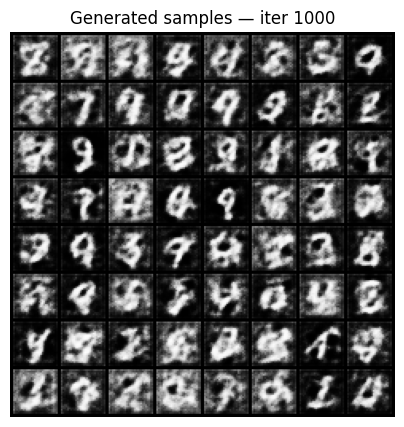

  KID (LeNet features) = 0.03291
  -> new best KID=0.03291 (saved checkpoints/best.pt)
[ 1200/10000] MMD2=3.6227  recon=0.0685  |code|=0.09  lr=1.00e-04  D=-1.3551  G=+1.9272  (387.6s)
[ 1400/10000] MMD2=3.3359  recon=0.0695  |code|=0.09  lr=1.00e-04  D=-1.2702  G=+1.8370  (452.0s)
[ 1600/10000] MMD2=2.8924  recon=0.0579  |code|=0.10  lr=1.00e-04  D=-1.2375  G=+1.9327  (516.8s)
[ 1800/10000] MMD2=3.5199  recon=0.0533  |code|=0.11  lr=1.00e-04  D=-1.4500  G=+1.7640  (581.5s)
[ 2000/10000] MMD2=3.5567  recon=0.0560  |code|=0.12  lr=1.00e-04  D=-1.4380  G=+1.7227  (645.5s)


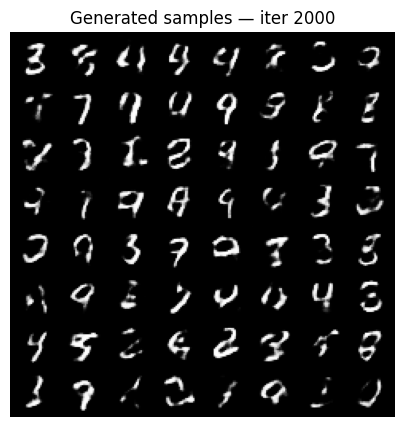

  KID (LeNet features) = 0.01727
  -> new best KID=0.01727 (saved checkpoints/best.pt)
[ 2200/10000] MMD2=2.7818  recon=0.0497  |code|=0.13  lr=1.00e-04  D=-1.2705  G=+1.6724  (710.4s)
[ 2400/10000] MMD2=3.2017  recon=0.0521  |code|=0.14  lr=1.00e-04  D=-1.3729  G=+1.8152  (774.7s)
[ 2600/10000] MMD2=3.2731  recon=0.0492  |code|=0.14  lr=1.00e-04  D=-1.4156  G=+1.7056  (838.9s)
[ 2800/10000] MMD2=2.4268  recon=0.0512  |code|=0.14  lr=1.00e-04  D=-1.1481  G=+1.6287  (903.0s)
[ 3000/10000] MMD2=3.1914  recon=0.0482  |code|=0.12  lr=1.00e-04  D=-1.4008  G=+1.7696  (967.8s)


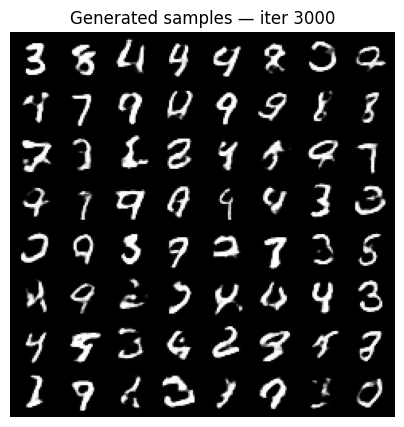

  KID (LeNet features) = 0.00438
  -> new best KID=0.00438 (saved checkpoints/best.pt)
[ 3200/10000] MMD2=2.5982  recon=0.0502  |code|=0.10  lr=1.00e-04  D=-1.2106  G=+1.5447  (1033.3s)
[ 3400/10000] MMD2=2.9685  recon=0.0468  |code|=0.09  lr=1.00e-04  D=-1.3488  G=+1.6139  (1097.5s)
[ 3600/10000] MMD2=2.7019  recon=0.0511  |code|=0.10  lr=1.00e-04  D=-1.2349  G=+1.5801  (1161.6s)
[ 3800/10000] MMD2=2.8528  recon=0.0508  |code|=0.10  lr=1.00e-04  D=-1.2823  G=+1.5398  (1225.6s)
[ 4000/10000] MMD2=2.8938  recon=0.0455  |code|=0.11  lr=1.00e-04  D=-1.3371  G=+1.7957  (1289.8s)


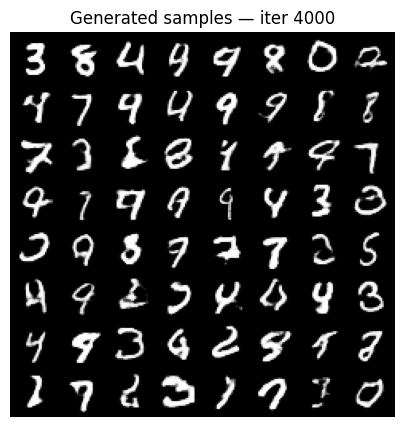

  KID (LeNet features) = 0.00348
  -> new best KID=0.00348 (saved checkpoints/best.pt)
[ 4200/10000] MMD2=3.0529  recon=0.0458  |code|=0.12  lr=1.00e-04  D=-1.3806  G=+1.6797  (1354.8s)
[ 4400/10000] MMD2=2.4217  recon=0.0423  |code|=0.13  lr=1.00e-04  D=-1.2178  G=+1.6173  (1419.6s)
[ 4600/10000] MMD2=2.5821  recon=0.0446  |code|=0.14  lr=1.00e-04  D=-1.2498  G=+1.6548  (1484.4s)
[ 4800/10000] MMD2=2.8612  recon=0.0455  |code|=0.13  lr=1.00e-04  D=-1.3272  G=+1.7256  (1549.2s)
[ 5000/10000] MMD2=2.2507  recon=0.0463  |code|=0.13  lr=1.00e-04  D=-1.1300  G=+1.6511  (1613.7s)


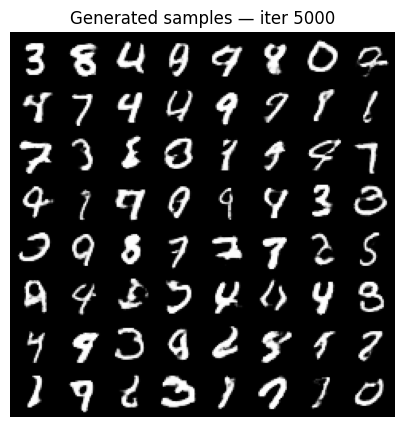

  KID (LeNet features) = 0.00246
  -> new best KID=0.00246 (saved checkpoints/best.pt)
[ 5200/10000] MMD2=2.7545  recon=0.0466  |code|=0.12  lr=1.00e-04  D=-1.2869  G=+1.6177  (1678.6s)
[ 5400/10000] MMD2=2.3733  recon=0.0456  |code|=0.13  lr=1.00e-04  D=-1.1759  G=+1.6407  (1742.9s)
[ 5600/10000] MMD2=2.6884  recon=0.0423  |code|=0.13  lr=1.00e-04  D=-1.3014  G=+1.6712  (1806.9s)
[ 5800/10000] MMD2=1.9182  recon=0.0453  |code|=0.13  lr=1.00e-04  D=-1.0222  G=+1.5894  (1871.5s)
[ 6000/10000] MMD2=2.7614  recon=0.0440  |code|=0.13  lr=1.00e-04  D=-1.3094  G=+1.5748  (1935.6s)


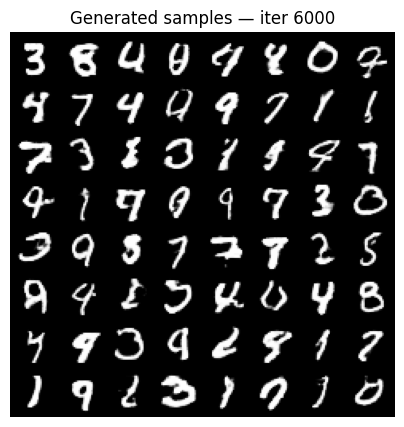

  KID (LeNet features) = 0.00221
  -> new best KID=0.00221 (saved checkpoints/best.pt)
[ 6200/10000] MMD2=3.0060  recon=0.0416  |code|=0.13  lr=1.00e-04  D=-1.4012  G=+1.6548  (2000.4s)
[ 6400/10000] MMD2=2.2570  recon=0.0487  |code|=0.14  lr=1.00e-04  D=-1.1130  G=+1.6474  (2064.9s)
[ 6600/10000] MMD2=2.7455  recon=0.0440  |code|=0.15  lr=1.00e-04  D=-1.3053  G=+1.5868  (2128.7s)
[ 6800/10000] MMD2=3.1927  recon=0.0425  |code|=0.14  lr=1.00e-04  D=-1.4471  G=+1.6221  (2192.9s)
[ 7000/10000] MMD2=2.9833  recon=0.0407  |code|=0.14  lr=1.00e-04  D=-1.4012  G=+1.5776  (2257.7s)


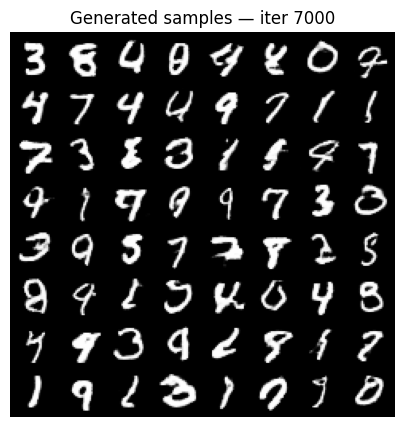

  KID (LeNet features) = 0.00210
  -> new best KID=0.00210 (saved checkpoints/best.pt)
[ 7200/10000] MMD2=2.7027  recon=0.0417  |code|=0.14  lr=1.00e-04  D=-1.3102  G=+1.7883  (2322.7s)
[ 7400/10000] MMD2=3.0963  recon=0.0433  |code|=0.15  lr=1.00e-04  D=-1.4129  G=+1.6132  (2387.5s)
[ 7600/10000] MMD2=2.2814  recon=0.0402  |code|=0.15  lr=1.00e-04  D=-1.1887  G=+1.5762  (2452.2s)
[ 7800/10000] MMD2=2.7085  recon=0.0390  |code|=0.16  lr=1.00e-04  D=-1.3334  G=+1.5590  (2517.0s)
[ 8000/10000] MMD2=2.6085  recon=0.0401  |code|=0.16  lr=1.00e-04  D=-1.2943  G=+1.6991  (2581.6s)


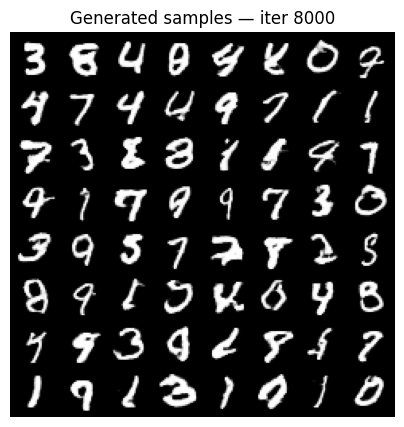

  KID (LeNet features) = 0.00220
[ 8200/10000] MMD2=2.2727  recon=0.0405  |code|=0.15  lr=1.00e-04  D=-1.1839  G=+1.7457  (2647.4s)
[ 8400/10000] MMD2=2.3795  recon=0.0406  |code|=0.15  lr=1.00e-04  D=-1.2180  G=+1.6765  (2711.9s)
[ 8600/10000] MMD2=3.0298  recon=0.0431  |code|=0.16  lr=1.00e-04  D=-1.3961  G=+1.5668  (2776.4s)
[ 8800/10000] MMD2=2.4973  recon=0.0423  |code|=0.16  lr=1.00e-04  D=-1.2420  G=+1.6852  (2841.0s)
[ 9000/10000] MMD2=2.7256  recon=0.0396  |code|=0.16  lr=1.00e-04  D=-1.3340  G=+1.5549  (2905.1s)


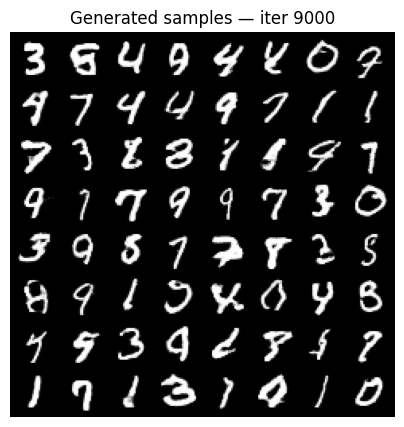

  KID (LeNet features) = 0.00242
[ 9200/10000] MMD2=2.8244  recon=0.0419  |code|=0.17  lr=1.00e-04  D=-1.3457  G=+1.6582  (2970.0s)
[ 9400/10000] MMD2=2.7892  recon=0.0399  |code|=0.17  lr=1.00e-04  D=-1.3506  G=+1.5840  (3033.9s)
[ 9600/10000] MMD2=2.7431  recon=0.0360  |code|=0.18  lr=1.00e-04  D=-1.3686  G=+1.6183  (3098.4s)
[ 9800/10000] MMD2=2.8513  recon=0.0410  |code|=0.19  lr=1.00e-04  D=-1.3608  G=+1.8239  (3163.1s)
[10000/10000] MMD2=2.8965  recon=0.0387  |code|=0.19  lr=1.00e-04  D=-1.3923  G=+1.6980  (3227.5s)


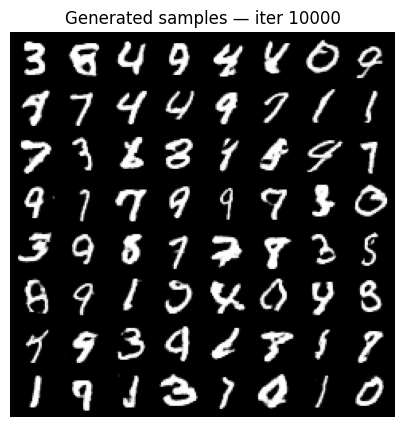

  KID (LeNet features) = 0.00195
  -> new best KID=0.00195 (saved checkpoints/best.pt)
Training done in 3228.1s  |  best KID=0.00195
Saved log to outputs/train_log.txt


In [20]:
history     = {'iter': [], 'mmd2': [], 'recon': [], 'code_norm': [],
               'd_loss': [], 'g_loss': [], 'lr': []}
samples_log = []
log_lines   = []

def log(msg):
    print(msg)
    log_lines.append(msg)

def show_grid(imgs, title='', save_path=None):
    grid = utils.make_grid(imgs.detach().cpu(), nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.title(title); plt.axis('off')
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show(); plt.close()

log(f'Training MMD-GAN (autoencoder critic)  n_critic={cfg.n_critic}  lambda_ae={cfg.lambda_ae}')
os.makedirs('checkpoints', exist_ok=True)
best_kid = float('inf')
start = time.time()

for it in range(1, cfg.n_iters + 1):

    # ── 1) Critic (encoder + decoder) updates ────────────────────────────────
    for _ in range(cfg.n_critic):
        real, _ = next(data_iter)
        real    = real.to(device, non_blocking=True)
        bs      = real.size(0)

        z = torch.randn(bs, cfg.z_dim, device=device)
        with torch.no_grad():
            fake = G(z)

        code_r, rec_r = D(real)
        code_f, rec_f = D(fake)

        mmd2  = mmd2_codes(code_r, code_f)
        recon = recon_loss(rec_r, real) + recon_loss(rec_f, fake)

        # Critic maximises sqrt(MMD) and minimises reconstruction error.
        d_loss = -torch.sqrt(mmd2 + EPS) + cfg.lambda_ae * recon
        opt_D.zero_grad(set_to_none=True)
        d_loss.backward()
        opt_D.step()

    # ── 2) Generator update (codes only) ─────────────────────────────────────
    z = torch.randn(cfg.batch_size, cfg.z_dim, device=device)
    fake = G(z)
    real, _ = next(data_iter)
    real = real.to(device, non_blocking=True)

    with torch.no_grad():
        code_r = D.encode(real)
    code_f = D.encode(fake)
    g_loss = mmd_sqrt(code_r, code_f)

    opt_G.zero_grad(set_to_none=True)
    g_loss.backward()
    opt_G.step()

    sched_G.step(); sched_D.step()

    # EMA update
    with torch.no_grad():
        for p_ema, p in zip(G_ema.parameters(), G.parameters()):
            p_ema.data.mul_(EMA_DECAY).add_(p.data, alpha=1 - EMA_DECAY)
        for b_ema, b in zip(G_ema.buffers(), G.buffers()):
            b_ema.data.copy_(b.data)

    # ── 3) Logging ───────────────────────────────────────────────────────────
    if it % cfg.log_every == 0 or it == 1:
        cur_lr    = opt_G.param_groups[0]['lr']
        code_norm = code_f.detach().norm(dim=1).mean().item()
        history['iter'].append(it)
        history['mmd2'].append(mmd2.item())
        history['recon'].append(recon.item())
        history['code_norm'].append(code_norm)
        history['d_loss'].append(d_loss.item())
        history['g_loss'].append(g_loss.item())
        history['lr'].append(cur_lr)
        dt = time.time() - start
        log(f'[{it:5d}/{cfg.n_iters}] '
            f'MMD2={mmd2.item():.4f}  '
            f'recon={recon.item():.4f}  '
            f'|code|={code_norm:.2f}  '
            f'lr={cur_lr:.2e}  '
            f'D={d_loss.item():+.4f}  '
            f'G={g_loss.item():+.4f}  '
            f'({dt:.1f}s)')

    if it % cfg.sample_every == 0 or it == cfg.n_iters:
        with torch.no_grad():
            samples = G_ema(z_fixed)
        samples_log.append((it, samples.cpu()))
        show_grid(samples, title=f'Generated samples — iter {it}',
                  save_path=os.path.join(IMG_DIR, f'samples_iter_{it:06d}.png'))

        kid = kid_estimate()
        history.setdefault('kid_iter', []).append(it)
        history.setdefault('kid', []).append(kid)
        log(f'  KID (LeNet features) = {kid:.5f}')

        ckpt = {'G': G.state_dict(), 'G_ema': G_ema.state_dict(),
                'D': D.state_dict(), 'it': it, 'kid': kid, 'history': history}
        torch.save(ckpt, f'checkpoints/ckpt_{it:06d}.pt')
        if kid < best_kid:
            best_kid = kid
            torch.save(ckpt, 'checkpoints/best.pt')
            log(f'  -> new best KID={best_kid:.5f} (saved checkpoints/best.pt)')

log(f'Training done in {time.time()-start:.1f}s  |  best KID={best_kid:.5f}')

with open(os.path.join(OUTPUT_DIR, 'train_log.txt'), 'w', encoding='utf-8') as f:
    for line in log_lines:
        f.write(line + chr(10))
print('Saved log to', os.path.join(OUTPUT_DIR, 'train_log.txt'))


## 9. Learning Curves

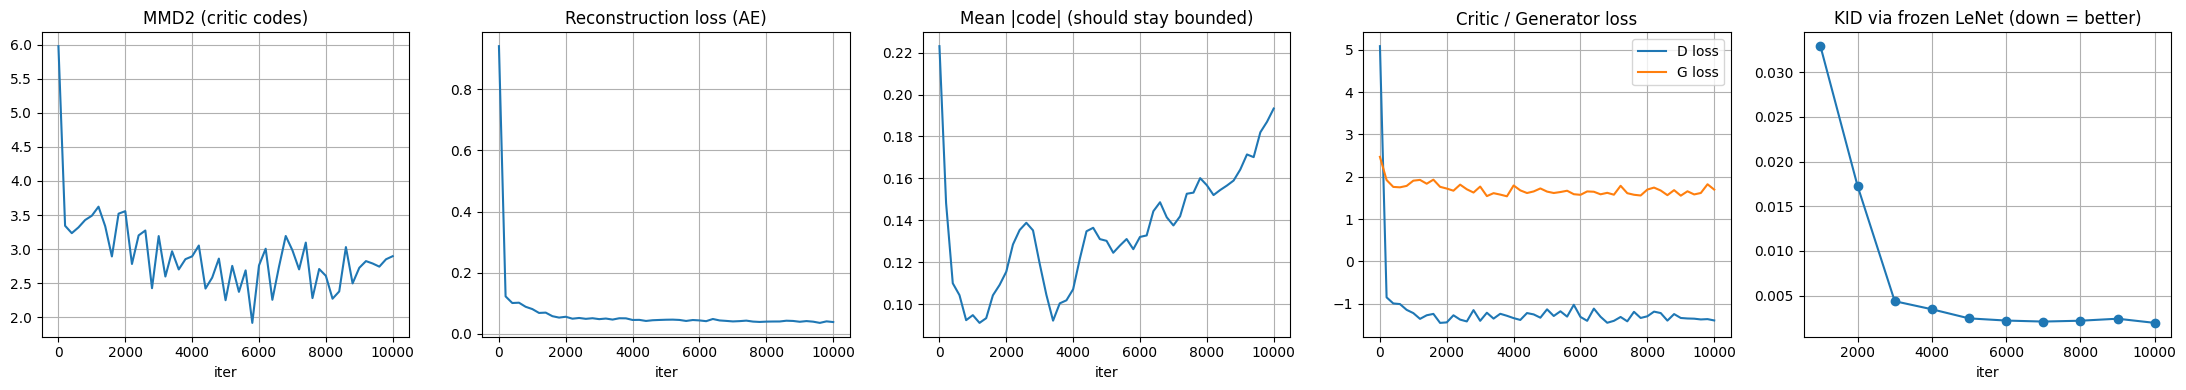

In [21]:
n_plots = 5
fig, axes = plt.subplots(1, n_plots, figsize=(22, 4))

axes[0].plot(history['iter'], history['mmd2'])
axes[0].set_title('MMD2 (critic codes)'); axes[0].set_xlabel('iter'); axes[0].grid(True)

axes[1].plot(history['iter'], history['recon'])
axes[1].set_title('Reconstruction loss (AE)'); axes[1].set_xlabel('iter'); axes[1].grid(True)

axes[2].plot(history['iter'], history['code_norm'])
axes[2].set_title('Mean |code| (should stay bounded)'); axes[2].set_xlabel('iter'); axes[2].grid(True)

axes[3].plot(history['iter'], history['d_loss'], label='D loss')
axes[3].plot(history['iter'], history['g_loss'], label='G loss')
axes[3].set_title('Critic / Generator loss'); axes[3].legend(); axes[3].grid(True)

if 'kid' in history and history['kid']:
    axes[4].plot(history['kid_iter'], history['kid'], marker='o')
    axes[4].set_title('KID via frozen LeNet (down = better)'); axes[4].set_xlabel('iter'); axes[4].grid(True)
else:
    axes[4].text(0.5, 0.5, 'KID not yet computed', ha='center', va='center',
                 transform=axes[4].transAxes)

plt.tight_layout()
save_fig('learning_curves.png'); plt.show(); plt.close()


## 10. Qualitative Sample Evolution

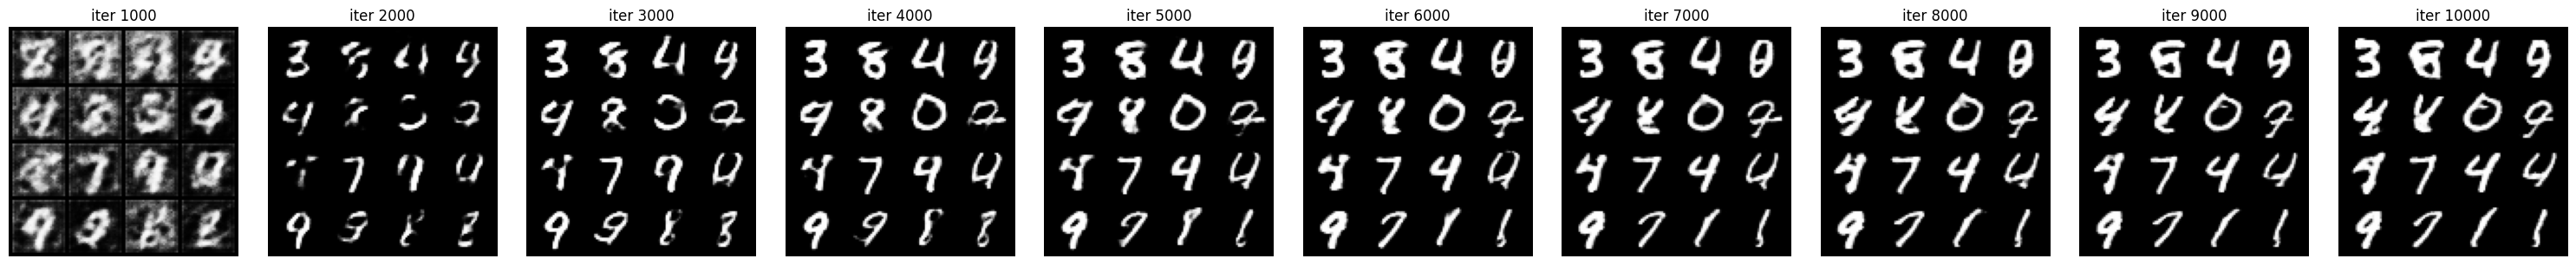

In [22]:
n_snaps = len(samples_log)
if n_snaps > 0:
    fig, axes = plt.subplots(1, n_snaps, figsize=(3 * n_snaps, 3))
    if n_snaps == 1:
        axes = [axes]
    for ax, (it, imgs) in zip(axes, samples_log):
        grid = utils.make_grid(imgs[:16], nrow=4, normalize=True, value_range=(-1, 1))
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f'iter {it}'); ax.axis('off')
    plt.tight_layout()
    save_fig('samples_evolution.png'); plt.show(); plt.close()
else:
    print('No samples logged yet.')


## 11. Final Generation and Save

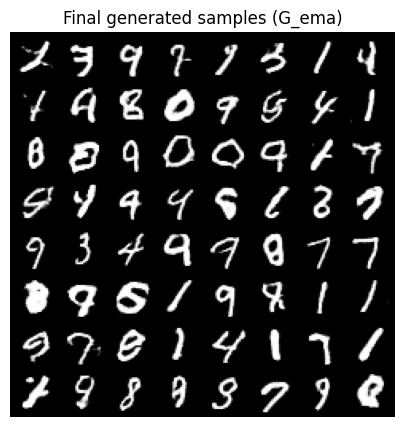

Model saved to checkpoints/mmd_gan_mnist_ae.pt
Artefacts written:
  - figures      -> outputs/images
  - text log     -> outputs/train_log.txt
  - history JSON -> outputs/history.json
  - best model   -> checkpoints/best.pt   (lowest KID seen during training)


In [23]:
with torch.no_grad():
    z_final = torch.randn(64, cfg.z_dim, device=device)
    samples = G_ema(z_final)
show_grid(samples, title='Final generated samples (G_ema)',
          save_path=os.path.join(IMG_DIR, 'final_samples.png'))

torch.save({
    'G':       G.state_dict(),
    'G_ema':   G_ema.state_dict(),
    'D':       D.state_dict(),
    'cfg':     cfg.__dict__,
    'history': history,
}, 'checkpoints/mmd_gan_mnist_ae.pt')
print('Model saved to checkpoints/mmd_gan_mnist_ae.pt')

with open(os.path.join(OUTPUT_DIR, 'history.json'), 'w', encoding='utf-8') as f:
    json.dump({'cfg': cfg.__dict__, 'history': history}, f, indent=2, ensure_ascii=False)

print('Artefacts written:')
print('  - figures      ->', IMG_DIR)
print('  - text log     ->', os.path.join(OUTPUT_DIR, 'train_log.txt'))
print('  - history JSON ->', os.path.join(OUTPUT_DIR, 'history.json'))
print('  - best model   -> checkpoints/best.pt   (lowest KID seen during training)')


## 12. Discussion and Next Steps

### What to expect

- **`recon` falls quickly** in the first hundreds of iterations (the critic learns to
  autoencode), then **`MMD2` becomes the active signal**. `|code|` should stay bounded
  (spectral norm) rather than drifting upward.
- **Recognisable digits within a few thousand generator iterations**, and **KID trending well
  below the ~3.0 plateau** of the previous broken run. `checkpoints/best.pt` always holds the
  lowest-KID model.
- No collapse to blank images: the reconstruction term penalises the encoder for ignoring
  image content, so the generator cannot win by going blank.

### Recovering the best model

```python
ckpt = torch.load('checkpoints/best.pt', map_location=device)
G_ema.load_state_dict(ckpt['G_ema'])
print('best KID', ckpt['kid'], 'at iter', ckpt['it'])
```

### Knobs

| Parameter | Suggested | Effect |
|---|---|---|
| `lambda_ae` | 4–16 (start 8) | Higher = more informative codes, weaker MMD pressure |
| `n_critic` | 3–5 | Critic strength per generator step (more = slower but steadier) |
| `feat_dim` | 16–64 | Code capacity |
| `SIGMAS` | match `|code|` | Kernel bandwidths; the mixture is forgiving |

### If runtime is a concern

`n_critic=5` makes each iteration ~5× the critic cost. For a quick look, drop `n_critic` to 2–3
and `n_iters` to ~15–20k — digits should already be clear.

### Next steps

1. **One-sided penalty** (reference `lambda_rg`): add `relu(mean(code_r) - mean(code_f))` to the
   objective for an extra moment-matching constraint.
2. **Kernel / metric ablation** across `SIGMAS`, comparing KID curves.
3. **CelebA 64×64** with a deeper encoder/decoder and the same recipe.
